 # Techniques to Handle Imbalanced Dataset
 


You create a classification model and the accuracy of this model is 95%. Everything is good.
 But you notice that your model always chooses the same class. When you examine the data set again, you see that the rate of the undetected class in the data set is 5%.
So the failure of your model is due to the imbalanced dataset.

Imbalanced classification refers to a classification predictive modeling problem where the number of examples in the training dataset for each class label is not balanced.There are several ways to deal with this problem.

- Change the performance metric

- Random Oversampling

- SMOTE Oversampling

- Random Undersampling

- NearMiss Undersampling

Brief explanations of the methods and how to apply them are shown in this book.

# Dataset

Our main objective with the dataset is to prioritize accuraltely classifying fraud.

In [1]:
# Libraries
import pandas as pd
from sklearn.metrics import confusion_matrix, classification_report,f1_score,recall_score,roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt 

In [2]:
# reading dataset
df = pd.read_csv("../input/creditcardfraud/creditcard.csv")

In [3]:
df.head()
df.Class.value_counts()

0    284315
1       492
Name: Class, dtype: int64

In [4]:
# RobustScaler is less prone to outliers.
rob_scaler = RobustScaler()
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.drop(['Time','Amount'], axis=1, inplace=True)

In [5]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.783274,-0.994983
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.269825,-0.994983
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,4.983721,-0.994972
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.418291,-0.994972
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.670579,-0.994960


In [6]:
# Ratio of classes
print('No Frauds', round(df['Class'].value_counts()[0]/len(df) * 100,2), '% of the dataset')
print('Frauds', round(df['Class'].value_counts()[1]/len(df) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


In [7]:
X = df.drop("Class", axis=1)
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=27)

# Change the performance metric

In [8]:
# Accuracy 0.999%
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.3f%%" % (accuracy))

Accuracy: 0.999%


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)




**Accuracy** is not the best metric to use when evaluating imbalanced datasets.

- **Confusion Matrix:** showing correct predictions and types of incorrect predictions.

- **Precision:** The number of true positives divided by all positive predictions. Low precision indicates a high number of false positives.

- **Recall:** The number of true positives divided by the number of positive values in the test data. Low recall indicates a high number of false negatives.

- **F1 Score**: the weighted average of precision and recall.

- **AUC:** is a graph showing the performance of a classification model at all classification thresholds. 

In [9]:
# confusion_matrix
confusion_matrix(y_test,y_pred)

array([[71062,     8],
       [   47,    85]])

In [10]:
# classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     71070
           1       0.91      0.64      0.76       132

    accuracy                           1.00     71202
   macro avg       0.96      0.82      0.88     71202
weighted avg       1.00      1.00      1.00     71202



In [11]:
# recall_score 
recall_score(y_test, y_pred)

0.6439393939393939

In [12]:
# f1_score
f1_score(y_test, y_pred)

0.7555555555555555

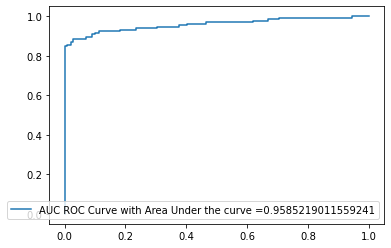

In [13]:
# Auc Roc Curve
def generate_auc_roc_curve(clf, X_test):
    y_pred_proba = clf.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = roc_curve(y_test,  y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    plt.plot(fpr,tpr,label="AUC ROC Curve with Area Under the curve ="+str(auc))
    plt.legend(loc=4)
    plt.show()
    pass

generate_auc_roc_curve(model, X_test)

Accuracy score is 0.999 but F1 score of only 0.75 and Recall score of only 0.64. When we examine the confusion matrix, we can see that many false observations have been made.

## **NOTE : Methods should be applied to the training set. If applied to the test set, correct evaluation cannot be made.**

# 1- Oversampling

Balances the data set by copying minority class samples.

## Random Oversampling

Addition of randomly selected samples from the minority class. This technique can be used if the data set is small. It may cause **overfitting**.

In [14]:
from imblearn.over_sampling import RandomOverSampler
# define oversampling strategy
#A floating point value can be specified to indicate the ratio of minority class majority examples in the transformed dataset. (0.5)
oversample = RandomOverSampler(sampling_strategy='minority')
# fit and apply the transform
X_randomover, y_randomover = oversample.fit_resample(X_train, y_train)

In [15]:
#before random oversampling
y_train.value_counts()

0    213245
1       360
Name: Class, dtype: int64

In [16]:
#after random oversampling
y_randomover.value_counts()

1    213245
0    213245
Name: Class, dtype: int64

In [17]:
model.fit(X_randomover, y_randomover)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.3f%%" % (accuracy))

Accuracy: 0.978%


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


In [18]:
# confusion_matrix
confusion_matrix(y_test,y_pred)

array([[69544,  1526],
       [   15,   117]])

In [19]:
# classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     71070
           1       0.07      0.89      0.13       132

    accuracy                           0.98     71202
   macro avg       0.54      0.93      0.56     71202
weighted avg       1.00      0.98      0.99     71202



In [20]:
# recall_score 
recall_score(y_test, y_pred)

0.8863636363636364

In [21]:
# f1_score
f1_score(y_test, y_pred)

0.13183098591549294

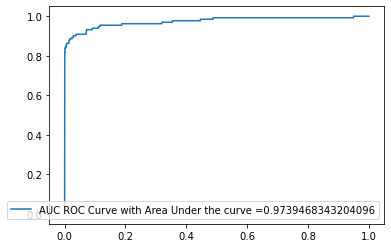

In [22]:
generate_auc_roc_curve(model, X_test)

The accuracy score of the model has dropped, but now the rate of correctly predicting within two classes has increased.

## SMOTE Oversampling 

Creating synthetic samples from minority class to prevent overfitting.

SMOTE first selects a minority class instance a at random and finds its k nearest minority class neighbors. 
The synthetic instance is then created by choosing one of the k nearest neighbors b at random and connecting a and b to form a line segment in the feature space. 
The synthetic instances are generated as a convex combination of the two chosen instances a and b.

In [23]:
from imblearn.over_sampling import SMOTE
# transform the dataset
oversample = SMOTE()
X_smote, y_smote = oversample.fit_resample(X_train, y_train)

In [24]:
#before smote oversampling
y_train.value_counts()

0    213245
1       360
Name: Class, dtype: int64

In [25]:
#after smote oversampling
y_smote.value_counts()

1    213245
0    213245
Name: Class, dtype: int64

In [26]:
#modelling
model.fit(X_smote, y_smote)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.3f%%" % (accuracy))

Accuracy: 0.977%


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


In [27]:
# confusion_matrix
confusion_matrix(y_test,y_pred)

array([[69468,  1602],
       [   15,   117]])

In [28]:
# classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     71070
           1       0.07      0.89      0.13       132

    accuracy                           0.98     71202
   macro avg       0.53      0.93      0.56     71202
weighted avg       1.00      0.98      0.99     71202



In [29]:
# recall_score 
recall_score(y_test, y_pred)

0.8863636363636364

In [30]:
# f1_score
f1_score(y_test, y_pred)

0.12641815235008103

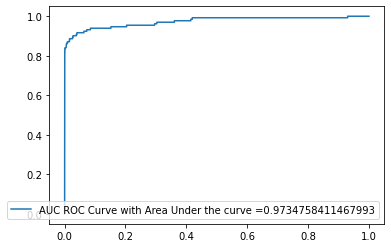

In [31]:
generate_auc_roc_curve(model, X_test)

# 2- Undersampling

It is the technique of balancing the data set by removing the samples belonging to the majority class.
You can use this technique if you have a large data set. Information may be lost due to random selection.

## Random Undersampling
The extracted samples are chosen at random. 

In [32]:
from imblearn.under_sampling import RandomUnderSampler
# transform the dataset
ranUnSample = RandomUnderSampler()
X_ranUnSample, y_ranUnSample = ranUnSample.fit_resample(X_train, y_train)

In [33]:
#before Random undersampling
y_train.value_counts()

0    213245
1       360
Name: Class, dtype: int64

In [34]:
#after Random undersampling
y_ranUnSample.value_counts()

1    360
0    360
Name: Class, dtype: int64

In [35]:
#modelling
model.fit(X_ranUnSample, y_ranUnSample)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.3f%%" % (accuracy))

Accuracy: 0.968%


In [36]:
# confusion_matrix
confusion_matrix(y_test,y_pred)

array([[68839,  2231],
       [   14,   118]])

In [37]:
# recall_score 
recall_score(y_test, y_pred)

0.8939393939393939

In [38]:
# f1_score
f1_score(y_test, y_pred)

0.0951229343006852

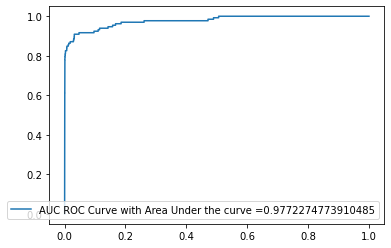

In [39]:
generate_auc_roc_curve(model, X_test)

The concern here is that the total number of samples we use to train the model is small.

## NearMiss Undersampling
It prevents the loss of information. It is based on the KNN algorithm. The distance between the samples belonging to the majority class and the samples belonging to the minority class is calculated. Samples whose distance is shorter than the specified value of k are preserved.

Three Version:

- NearMiss-1: Majority class examples with minimum average distance to three closest minority class examples.
- NearMiss-2: Majority class examples with minimum average distance to three furthest minority class examples.
- NearMiss-3: Majority class examples with minimum distance to each minority class example.


The NearMiss-3 seems desirable, given that it will only keep those majority class examples that are on the decision boundary

In [40]:
from imblearn.under_sampling import NearMiss
# define the undersampling method
NearMiss1 = NearMiss(version=3)
X_nearMiss, y_nearMiss = NearMiss1.fit_resample(X_train, y_train)

/opt/conda/lib/python3.7/site-packages/imblearn/under_sampling/_prototype_selection/_nearmiss.py:178: UserWarning: The number of the samples to be selected is larger than the number of samples available. The balancing ratio cannot be ensure and all samples will be returned.
  "The number of the samples to be selected is larger"


In [41]:
y_nearMiss.value_counts()

1    360
0    322
Name: Class, dtype: int64

In [42]:
#modelling
model.fit(X_nearMiss, y_nearMiss)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy: %.3f%%" % (accuracy))

Accuracy: 0.892%


/opt/conda/lib/python3.7/site-packages/sklearn/linear_model/_logistic.py:764: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)


In [43]:
# confusion_matrix
confusion_matrix(y_test,y_pred)

array([[63391,  7679],
       [   32,   100]])

In [44]:
# recall_score 
recall_score(y_test, y_pred)

0.7575757575757576

In [45]:
# f1_score
f1_score(y_test, y_pred)

0.02528125395019593

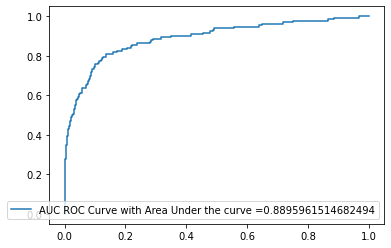

In [46]:
generate_auc_roc_curve(model, X_test)